# Denoising Autoencoder (Salt & Pepper) on Oxford-IIIT Pet — PyTorch

Plain convolutional autoencoder with **no skip connections**, ported from Keras to PyTorch. The encoder uses two stages, and a separately configurable bottleneck produces the 32×32 latent representation for 128×128 inputs.

## Plan
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Imports, config (image size, noise level, epochs), device |
| 2 | Data | Load the repository's local Oxford-IIIT Pet images and official train / val / test splits |
| 3 | Noise | GPU function adding salt & pepper noise on the fly; visual sanity check |
| 4 | Model | No-skip convolutional autoencoder with a configurable 32×32 bottleneck |
| 5 | Train | Adam + weighted L1/SSIM loss, fresh noise every batch, track train/val loss |
| 6 | Curves | Plot loss, pick best epoch |
| 7 | Test | PSNR and SSIM on the held-out test split: noisy vs. denoised |
| 8 | Visuals | Noisy / denoised / clean grid |
| 9 | Robustness | Sweep noise density to see how the model copes with levels it wasn't trained on |
| 10 | Baseline | Compare against a 3×3 median filter (the classic S&P fix) |
| 11 | Save | Save and reload weights |

**Differences from the article:** noise is regenerated every batch (not fixed once), salt & pepper replaces Gaussian, and the model is evaluated with PSNR/SSIM as the article's "What Next?" suggests.


## 1. Setup

In [1]:
!pip install -q torchmetrics scipy optuna wandb

import gc, time, random, json
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import optuna
import wandb
from optuna.trial import TrialState
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional import structural_similarity_index_measure

# ---------------- config ----------------
IMG_SIZE    = 128      # the article uses 240; 128 is faster and lighter on memory
BATCH_SIZE  = 32
EPOCHS      = 30
TRIALS      = 20
TRIAL_EPOCHS = 8

# Explicit Optuna search space
OPTUNA_SEARCH_SPACE = {
    "batch_size": [16, 32, 64],
    "base_channels": [32, 48, 64],
    "bottleneck_channels": [32, 64, 96, 128],
    "learning_rate": {"low": 1e-4, "high": 3e-3, "log": True},
    "alpha": {"low": 0.60, "high": 0.95},
}
LR          = 1e-3
TRAIN_NOISE = 0.10     # fraction of pixels corrupted (half salt, half pepper)
SEED        = 42
NUM_WORKERS = 2
WANDB_PROJECT = "genai-assignment-1"
WANDB_RUN_NAME = "dae-salt-pepper-optuna"
# ----------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "corruption": "salt_and_pepper", "image_size": IMG_SIZE,
        "epochs": EPOCHS, "optuna_trials": TRIALS, "trial_epochs": TRIAL_EPOCHS,
        "seed": SEED, "train_noise_density": TRAIN_NOISE,
        "search_space": OPTUNA_SEARCH_SPACE,
    },
)


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Data — local Oxford-IIIT Pet dataset
Images and official split manifests are read from the repository's `research/datasets` folder. This avoids downloading another copy from torchvision.


In [2]:
# Find the repository root from either the repo root or research/notebooks as the Jupyter working directory.
_here = Path.cwd().resolve()
_repo_candidates = [_here, *_here.parents]
REPO_ROOT = next(
    (p for p in _repo_candidates if (p / "research/datasets/oxford-iiit-pet/images").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find research/datasets/oxford-iiit-pet/images. "
        "Run this notebook from within the repository."
    )

PET_IMAGES_DIR = REPO_ROOT / "research/datasets/oxford-iiit-pet/images"
SPLIT_MANIFEST = REPO_ROOT / "research/split_manifest_official.json"
if not SPLIT_MANIFEST.is_file():
    raise FileNotFoundError(f"Official split manifest not found: {SPLIT_MANIFEST}")
with SPLIT_MANIFEST.open() as f:
    split_manifest = json.load(f)

class LocalPetImages(Dataset):
    """Clean Oxford-IIIT Pet images loaded from the repository's dataset folder."""
    def __init__(self, filenames, transform):
        self.paths = [PET_IMAGES_DIR / name for name in filenames]
        missing = [path for path in self.paths if not path.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing dataset image, for example: {missing[0]}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            clean = self.transform(image.convert("RGB"))
        # The training code ignores labels; return a placeholder for its existing batch format.
        return clean, 0

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),            # float in [0, 1], shape (3, H, W)
])

train_ds = LocalPetImages(split_manifest["train"], tfm)
val_ds   = LocalPetImages(split_manifest["val"], tfm)
test_ds  = LocalPetImages(split_manifest["test"], tfm)
print(f"Dataset: {PET_IMAGES_DIR}")
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# labels are ignored: the target is the clean image itself
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Dataset: /home/zaifi/genai-assignment-1/research/datasets/oxford-iiit-pet/images
train=2944  val=736  test=3669


## 3. Salt & pepper noise

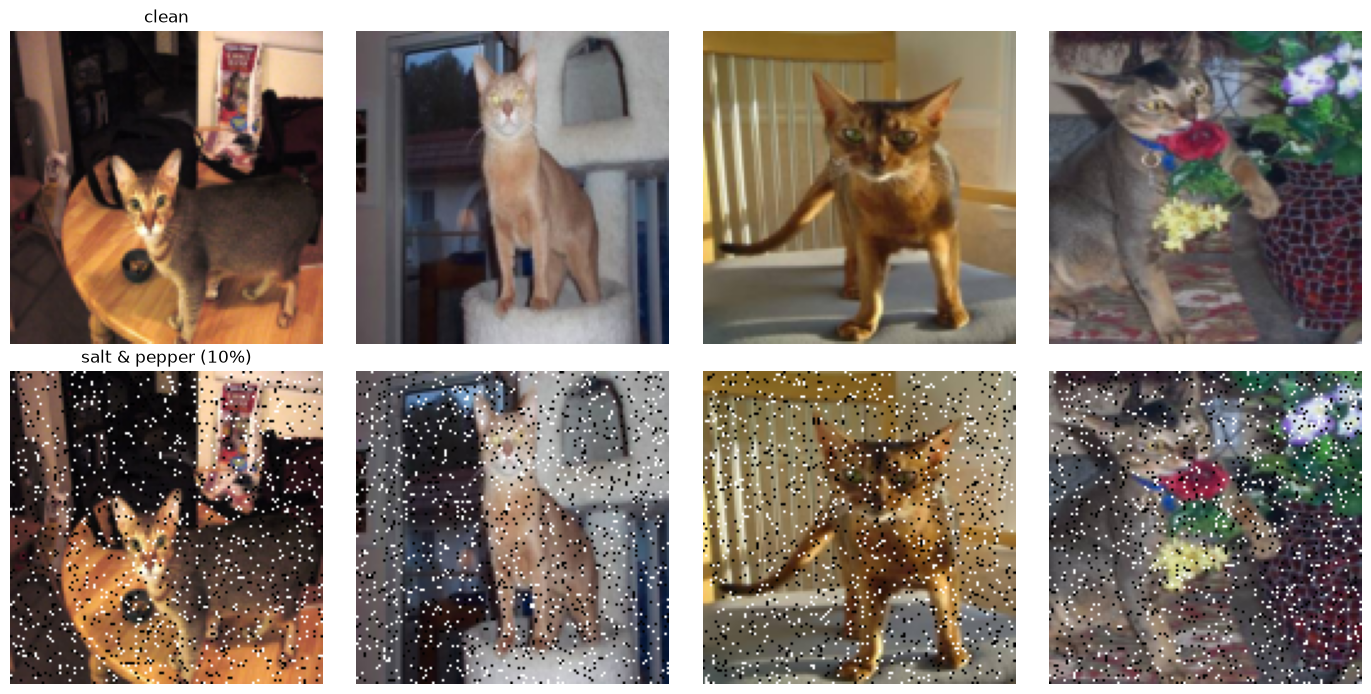

In [3]:
def add_salt_pepper(x, amount=0.10, salt_vs_pepper=0.5, generator=None):
    """x: (B, C, H, W) in [0, 1]. `amount` = fraction of pixels corrupted.
    A corrupted pixel is set to 1 (salt) or 0 (pepper) across all channels."""
    B, C, H, W = x.shape
    r = torch.rand(B, 1, H, W, device=x.device, generator=generator)
    pepper = r < amount * (1 - salt_vs_pepper)
    salt   = (r >= amount * (1 - salt_vs_pepper)) & (r < amount)
    noisy = x.masked_fill(pepper.expand_as(x), 0.0)
    noisy = noisy.masked_fill(salt.expand_as(x), 1.0)
    return noisy

# visual sanity check
x, _ = next(iter(test_loader))
x = x[:4].to(device)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    ax[0, i].imshow(x[i].permute(1, 2, 0).cpu());                              ax[0, i].axis("off")
    ax[1, i].imshow(add_salt_pepper(x, 0.10)[i].permute(1, 2, 0).cpu());       ax[1, i].axis("off")
ax[0, 0].set_title("clean"); ax[1, 0].set_title("salt & pepper (10%)")
plt.tight_layout(); plt.show()

## 4. Model
The encoder has two two-convolution stages. In each stage, the first convolution changes the channel width while preserving spatial size, and the second keeps the width while halving spatial size. A separate bottleneck convolution sets the latent channel count at 32×32 resolution. The two-stage decoder reverses the encoder widths while upsampling to the original resolution, with no skip connections.


In [4]:
class DenoisingAE(nn.Module):
    def __init__(self, base_channels=64, bottleneck_channels=128):
        super().__init__()
        c1 = base_channels
        c2 = base_channels * 2

        # Each stage first changes channels at fixed resolution, then downsamples.
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(c1, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        # The bottleneck width is searched independently from encoder width.
        self.bottleneck = nn.Sequential(
            nn.Conv2d(c2, bottleneck_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Mirror the encoder without concatenating any encoder features.
        self.dec2 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c1, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(c1, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.bottleneck(self.enc2(self.enc1(x)))

    def forward(self, x):
        z = self.encode(x)  # (B, bottleneck_channels, H/4, W/4)
        x = F.interpolate(z, scale_factor=2, mode="bilinear")
        x = self.dec2(x)
        x = F.interpolate(x, scale_factor=2, mode="bilinear")
        return self.dec1(x)

model = DenoisingAE(base_channels=64).to(device)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    print("Bottleneck:", tuple(model.encode(dummy).shape), "| Output:", tuple(model(dummy).shape))


DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (dec2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dec1): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 3, k

## 5. Optuna search and final training

Optuna minimizes the validation value of the same weighted L1 + (1 − SSIM) loss used for training. The search space is declared explicitly in `OPTUNA_SEARCH_SPACE`: batch size `{16, 32, 64}`, base channels `{32, 48, 64}`, bottleneck channels `{32, 64, 96, 128}`, learning rate `1e-4` to `3e-3` on a log scale, and loss weight `alpha` from `0.60` to `0.95`. Trials use a short schedule; the winning configuration is then trained for the original 30 epochs, with the best validation checkpoint retained. Validation noise is fixed across epochs and trials for a fair comparison.

[I 2026-10-04 08:40:17,821] A new study created in RDB with name: dae_saltpepper_simple_optuna
/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Trial 000 | epoch 01/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1932 val=0.1161
Trial 000 | epoch 02/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1096 val=0.1070
Trial 000 | epoch 03/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1006 val=0.0965
Trial 000 | epoch 04/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.0949 val=0.0920
Trial 000 | epoch 05/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.0918 val=0.0899
Trial 000 | epoch 06/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.0896 val=0.0890
Trial 000 | epoch 07/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.0883 val=0.0870
Trial 000 | epoch 08/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.0863 val=0.0864


[I 2026-10-04 08:41:27,468] Trial 0 finished with value: 0.08637635409832001 and parameters: {'batch_size': 32, 'base_channels': 32, 'bottleneck_channels': 64, 'lr': 0.00010725209743172001, 'alpha': 0.939468448256698}. Best is trial 0 with value: 0.08637635409832001.


Trial 001 | epoch 01/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1927 val=0.1446
Trial 001 | epoch 02/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1263 val=0.1072
Trial 001 | epoch 03/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0997 val=0.0934
Trial 001 | epoch 04/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0882 val=0.0842
Trial 001 | epoch 05/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0823 val=0.0788
Trial 001 | epoch 06/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0773 val=0.0750
Trial 001 | epoch 07/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0748 val=0.0720
Trial 001 | epoch 08/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.0721 val=0.0697


[I 2026-10-04 08:43:03,214] Trial 1 finished with value: 0.06974117044845353 and parameters: {'batch_size': 16, 'base_channels': 64, 'bottleneck_channels': 96, 'lr': 0.00027010527749605503, 'alpha': 0.7282266451527921}. Best is trial 1 with value: 0.06974117044845353.


...

Trial 018 | epoch 01/8 | batch=32 base=64 bottleneck=128 alpha=0.807 lr=0.00077 | train=0.1734 val=0.1342
Trial 018 | epoch 02/8 | batch=32 base=64 bottleneck=128 alpha=0.807 lr=0.00077 | train=0.1080 val=0.0865
Trial 018 | epoch 03/8 | batch=32 base=64 bottleneck=128 alpha=0.807 lr=0.00077 | train=0.0823 val=0.0737
Trial 018 | epoch 04/8 | batch=32 base=64 bottleneck=128 alpha=0.807 lr=0.00077 | train=0.0728 val=0.0675


[I 2026-10-04 08:57:53,875] Trial 18 pruned. 


Trial 019 | epoch 01/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.1162 val=0.0836
Trial 019 | epoch 02/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0681 val=0.0588
Trial 019 | epoch 03/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0551 val=0.0575
Trial 019 | epoch 04/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0494 val=0.0474
Trial 019 | epoch 05/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0466 val=0.0438
Trial 019 | epoch 06/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0452 val=0.0421
Trial 019 | epoch 07/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0421 val=0.0398
Trial 019 | epoch 08/8 | batch=16 base=64 bottleneck=64 alpha=0.901 lr=0.00095 | train=0.0401 val=0.0363


[I 2026-10-04 08:59:13,942] Trial 19 finished with value: 0.03634842444697152 and parameters: {'batch_size': 16, 'base_channels': 64, 'bottleneck_channels': 64, 'lr': 0.0009465946337743738, 'alpha': 0.901415526208988}. Best is trial 19 with value: 0.03634842444697152.


Complete trials: 13 | pruned trials: 7
Best validation loss: 0.03634842444697152
Best parameters: {'batch_size': 16, 'base_channels': 64, 'bottleneck_channels': 64, 'lr': 0.0009465946337743738, 'alpha': 0.901415526208988}


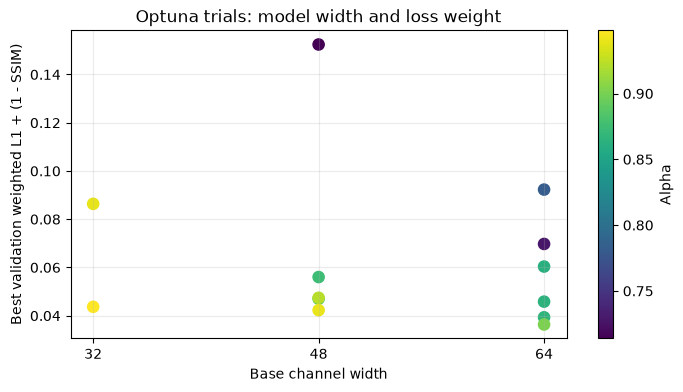

Epoch 01/30 train=0.1161 val=0.0887 (10s)
Epoch 02/30 train=0.0695 val=0.0583 (10s)
Epoch 03/30 train=0.0555 val=0.0545 (10s)
Epoch 04/30 train=0.0514 val=0.0465 (10s)
Epoch 05/30 train=0.0468 val=0.0441 (10s)
Epoch 06/30 train=0.0440 val=0.0418 (10s)
Epoch 07/30 train=0.0421 val=0.0385 (10s)
Epoch 08/30 train=0.0398 val=0.0400 (10s)
Epoch 09/30 train=0.0370 val=0.0347 (11s)
Epoch 10/30 train=0.0354 val=0.0353 (14s)
Epoch 11/30 train=0.0342 val=0.0355 (15s)


In [ ]:
# Assignment Task 1 loss: alpha * L1 + (1 - alpha) * (1 - SSIM).
def ae_loss(pred, target, alpha):
    l1 = F.l1_loss(pred, target)
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return alpha * l1 + (1.0 - alpha) * (1.0 - ssim)

def run_epoch(model, loader, optimizer=None, alpha=0.8, seed=None):
    training = optimizer is not None
    model.train(training)
    gen = None
    if seed is not None:
        gen = torch.Generator(device=device)
        gen.manual_seed(seed)
    total, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)
            out = model(noisy)
            loss = ae_loss(out, clean, alpha)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0)
            n += clean.size(0)
    return total / n

def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader

def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", OPTUNA_SEARCH_SPACE["batch_size"])
    base_channels = trial.suggest_categorical("base_channels", OPTUNA_SEARCH_SPACE["base_channels"])
    bottleneck_channels = trial.suggest_categorical("bottleneck_channels", OPTUNA_SEARCH_SPACE["bottleneck_channels"])
    lr_space = OPTUNA_SEARCH_SPACE["learning_rate"]
    lr = trial.suggest_float("lr", lr_space["low"], lr_space["high"], log=lr_space["log"])
    alpha_space = OPTUNA_SEARCH_SPACE["alpha"]
    alpha = trial.suggest_float("alpha", alpha_space["low"], alpha_space["high"])
    random.seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)
    torch.manual_seed(SEED + trial.number)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + trial.number)

    train_loader, val_loader = make_loaders(batch_size)
    trial_model = DenoisingAE(base_channels=base_channels, bottleneck_channels=bottleneck_channels).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    best_trial_val = float("inf")
    try:
        for epoch in range(1, TRIAL_EPOCHS + 1):
            train_loss = run_epoch(trial_model, train_loader, optimizer, alpha=alpha)
            val_loss = run_epoch(trial_model, val_loader, alpha=alpha, seed=SEED)
            best_trial_val = min(best_trial_val, val_loss)
            trial.report(val_loss, step=epoch)
            wandb.log({
                "optuna/trial": trial.number, "optuna/epoch": epoch,
                "optuna/train_loss": train_loss, "optuna/validation_loss": val_loss,
                "optuna/best_validation_loss": best_trial_val,
                "optuna/batch_size": batch_size, "optuna/base_channels": base_channels,
                "optuna/bottleneck_channels": bottleneck_channels,
                "optuna/learning_rate": lr, "optuna/alpha": alpha,
            })
            print(
                f"Trial {trial.number:03d} | epoch {epoch:02d}/{TRIAL_EPOCHS} | "
                f"batch={batch_size} base={base_channels} bottleneck={bottleneck_channels} "
                f"alpha={alpha:.3f} lr={lr:.2g} | "
                f"train={train_loss:.4f} val={val_loss:.4f}"
            )
            if trial.should_prune():
                raise optuna.TrialPruned()
        return best_trial_val
    finally:
        del trial_model, optimizer, train_loader, val_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

STUDY_NAME = "dae_saltpepper_simple_optuna"
STORAGE = f"sqlite:///{REPO_ROOT / 'research/notebooks/dae_saltpepper_simple_optuna.db'}"
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=pruner,
)
study.optimize(objective, n_trials=TRIALS)

completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
pruned_trials = [t for t in study.trials if t.state == TrialState.PRUNED]
print(f"Complete trials: {len(completed_trials)} | pruned trials: {len(pruned_trials)}")
print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)
wandb.config.update({f"best_{key}": value for key, value in study.best_params.items()})
wandb.summary["optuna/best_validation_loss"] = study.best_value

# Visualize completed trials by channel width, with color showing alpha.
plt.figure(figsize=(8, 4))
plt.scatter(
    [t.params["base_channels"] for t in completed_trials],
    [t.value for t in completed_trials],
    c=[t.params["alpha"] for t in completed_trials], cmap="viridis", s=65,
)
plt.xticks([32, 48, 64])
plt.xlabel("Base channel width")
plt.ylabel("Best validation weighted L1 + (1 - SSIM)")
plt.title("Optuna trials: model width and loss weight")
plt.colorbar(label="Alpha")
plt.grid(alpha=0.25)
plt.show()

# Retrain the best configuration with the source notebook's full training schedule.
best_params = study.best_params
ALPHA = best_params["alpha"]
LR = best_params["lr"]
BATCH_SIZE = best_params["batch_size"]
BASE_CHANNELS = best_params["base_channels"]
BOTTLENECK_CHANNELS = best_params["bottleneck_channels"]
set_seed(SEED)
train_loader, val_loader = make_loaders(BATCH_SIZE)
model = DenoisingAE(base_channels=BASE_CHANNELS, bottleneck_channels=BOTTLENECK_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"loss": [], "val_loss": []}
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer, alpha=ALPHA)
    va = run_epoch(model, val_loader, alpha=ALPHA, seed=SEED)
    history["loss"].append(tr)
    history["val_loss"].append(va)
    wandb.log({"epoch": epoch, "train/loss": tr, "validation/loss": va, "learning_rate": LR})
    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(
        f"Epoch {epoch:02d}/{EPOCHS} train={tr:.4f} val={va:.4f} "
        f"({time.time() - t0:.0f}s)"
    )

model.load_state_dict(best_state)
model.to(device).eval()
print(f"Best val loss: {best_val:.4f} | batch={BATCH_SIZE} | base={BASE_CHANNELS} | bottleneck={BOTTLENECK_CHANNELS} | alpha={ALPHA:.3f} | lr={LR:.2g}")


## 6. Loss curves

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", label="best epoch")
plt.title(f"Training and Validation Loss (L1 + SSIM, alpha={ALPHA:g})"); plt.xlabel("Epoch"); plt.ylabel("Weighted L1 + (1 - SSIM) loss")
plt.legend(); plt.show()


## 7. Test-set evaluation (PSNR / SSIM)
A fixed seed means the *same* corrupted test images are used every time you run this.

In [ ]:
def psnr_batch(a, b):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)          # per-image PSNR, data range [0, 1]

@torch.no_grad()
def evaluate(model, loader, amount, seed=123):
    model.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    ssim_n = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_d = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    p_n, p_d = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_salt_pepper(clean, amount, generator=gen)
        den   = model(noisy)
        p_n.append(psnr_batch(noisy, clean)); p_d.append(psnr_batch(den, clean))
        ssim_n.update(noisy, clean);          ssim_d.update(den, clean)
    return dict(psnr_noisy=torch.cat(p_n).mean().item(), psnr_denoised=torch.cat(p_d).mean().item(),
                ssim_noisy=ssim_n.compute().item(),      ssim_denoised=ssim_d.compute().item())

res = evaluate(model, test_loader, TRAIN_NOISE)
print(f"Noise density: {TRAIN_NOISE:.0%}")
print(f"PSNR  noisy: {res['psnr_noisy']:.2f} dB  ->  denoised: {res['psnr_denoised']:.2f} dB")
print(f"SSIM  noisy: {res['ssim_noisy']:.4f}     ->  denoised: {res['ssim_denoised']:.4f}")
wandb.log({
    "test/noise_density": TRAIN_NOISE,
    **{f"test/{key}": value for key, value in res.items()},
})

## 8. Visual results

In [ ]:
@torch.no_grad()
def show_results(model, dataset, amount=TRAIN_NOISE, n=6, seed=7):
    model.eval()
    idx = random.Random(seed).sample(range(len(dataset)), n)
    clean = torch.stack([dataset[i][0] for i in idx]).to(device)
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    noisy = add_salt_pepper(clean, amount, generator=gen)
    den = model(noisy)
    p_n, p_d = psnr_batch(noisy, clean), psnr_batch(den, clean)

    rows = [("Noisy", noisy, p_n), ("Denoised", den, p_d), ("Clean", clean, None)]
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 8))
    for r, (name, imgs, p) in enumerate(rows):
        for c in range(n):
            ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).cpu()); ax[r, c].axis("off")
            if p is not None: ax[r, c].set_title(f"{name}\n{p[c]:.1f} dB", fontsize=9)
            else:             ax[r, c].set_title(name, fontsize=9)
    plt.tight_layout(); plt.show()

show_results(model, test_ds)

## 9. Robustness: different noise densities
The model was trained at one density. This shows how it behaves on lighter and heavier noise.

In [ ]:
levels = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
rows = []
for a in levels:
    r = evaluate(model, test_loader, a)
    rows.append((a, r["psnr_noisy"], r["psnr_denoised"], r["ssim_noisy"], r["ssim_denoised"]))
    print(f"{a:>4.0%} | PSNR {r['psnr_noisy']:5.2f} -> {r['psnr_denoised']:5.2f} dB | SSIM {r['ssim_noisy']:.3f} -> {r['ssim_denoised']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(levels, [r[1] for r in rows], "o-", label="noisy");    ax[0].plot(levels, [r[2] for r in rows], "o-", label="denoised")
ax[0].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[0].set(title="PSNR vs noise density", xlabel="density", ylabel="dB"); ax[0].legend()
ax[1].plot(levels, [r[3] for r in rows], "o-", label="noisy");    ax[1].plot(levels, [r[4] for r in rows], "o-", label="denoised")
ax[1].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[1].set(title="SSIM vs noise density", xlabel="density", ylabel="SSIM"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Baseline: 3×3 median filter
Median filtering is the classic fix for salt & pepper noise. The autoencoder should beat or at least match it; if not, it needs more training or capacity.

In [ ]:
from scipy.ndimage import median_filter

N = 200  # number of test images (CPU filtering is slow)
gen = torch.Generator(device=device); gen.manual_seed(123)
clean = torch.stack([test_ds[i][0] for i in range(N)]).to(device)
noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)

with torch.no_grad():
    model.eval()
    ae_out = torch.cat([model(noisy[i:i+32]) for i in range(0, N, 32)])

med = np.stack([median_filter(img, size=(1, 3, 3)) for img in noisy.cpu().numpy()])   # (N, C, H, W)
med = torch.from_numpy(med).to(device)

print(f"Noisy        : {psnr_batch(noisy, clean).mean():.2f} dB")
print(f"Median 3x3   : {psnr_batch(med,   clean).mean():.2f} dB")
print(f"Autoencoder  : {psnr_batch(ae_out, clean).mean():.2f} dB")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
for a, (t, im) in zip(ax, [("Noisy", noisy[0]), ("Median 3x3", med[0]), ("Autoencoder", ae_out[0]), ("Clean", clean[0])]):
    a.imshow(im.permute(1, 2, 0).clamp(0, 1).cpu()); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 11. Save / load

In [ ]:
# Save the selected model and Optuna parameters in the repository's research/checkpoints folder.
checkpoint_path = REPO_ROOT / "research/checkpoints/dae_saltpepper_simple_optuna_best.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "train_noise": TRAIN_NOISE,
    "batch_size": BATCH_SIZE,
    "base_channels": BASE_CHANNELS,
    "bottleneck_channels": BOTTLENECK_CHANNELS,
    "alpha": ALPHA,
    "learning_rate": LR,
    "best_val_loss": best_val,
    "optuna_best_params": best_params,
}, checkpoint_path)
print("Saved:", checkpoint_path)

# Reload and verify the selected architecture and weights.
ckpt = torch.load(checkpoint_path, map_location=device)
model2 = DenoisingAE(
    base_channels=ckpt["base_channels"],
    bottleneck_channels=ckpt["bottleneck_channels"],
).to(device)
model2.load_state_dict(ckpt["state_dict"])
model2.eval()
print("Reloaded OK. Test PSNR:", round(evaluate(model2, test_loader, TRAIN_NOISE)["psnr_denoised"], 2), "dB")
model_artifact = wandb.Artifact(
    name=f"{WANDB_RUN_NAME}-model", type="model",
    metadata={"best_validation_loss": best_val, **best_params},
)
model_artifact.add_file(str(checkpoint_path))
wandb.log_artifact(model_artifact)
wandb.finish()


## Next steps
- Train with a random noise density per batch (for example, 0.05–0.4) to improve robustness across section 9's noise sweep.
- Make a U-Net variant by concatenating encoder feature maps into the decoder, then compare it against this no-skip baseline.
- Compare the winning Optuna configuration with the fixed `batch_size=32`, `base_channels=64`, `bottleneck_channels=128`, `alpha=0.8`, `lr=1e-3` baseline.